<a href="https://colab.research.google.com/github/sonixx00/Starshun/blob/main/LB9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Старшун Софія, ФІТ 2-17

Аналітичний вигляд кубічного сплайну:
Відрізок 1 [x_0, x_1]:
S_0(x) = 1.42 + 9.6436(x - 0.8) + 0.0000(x - 0.8)^2 + -44.3621(x - 0.8)^3
Відрізок 2 [x_1, x_2]:
S_1(x) = 2.34 + 8.3128(x - 0.9) + -13.3086(x - 0.9)^2 + -5.7796(x - 0.9)^3
Відрізок 3 [x_2, x_3]:
S_2(x) = 3.48 + -1.2329(x - 1.2) + -18.5103(x - 1.2)^2 + 27.2628(x - 1.2)^3
Відрізок 4 [x_3, x_4]:
S_3(x) = 1.77 + -2.9550(x - 1.6) + 14.2051(x - 1.6)^2 + -9.4700(x - 1.6)^3


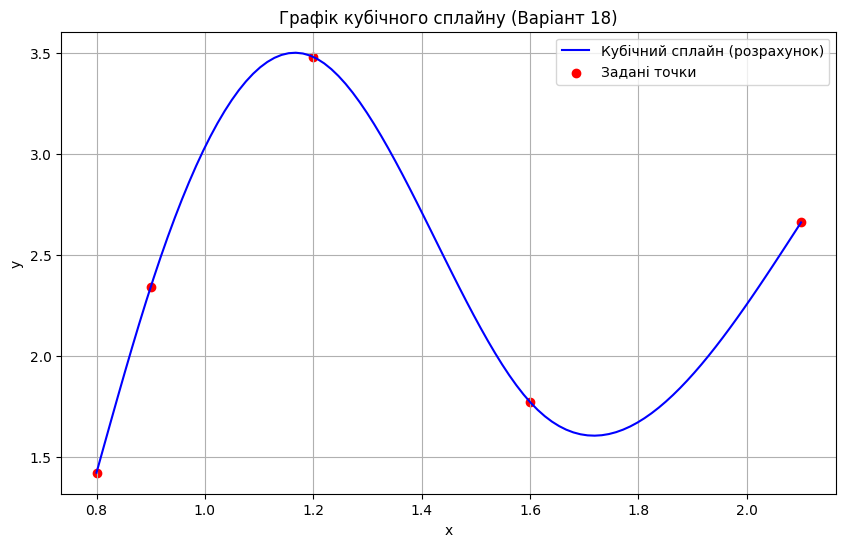


Коефіцієнти через SciPy CubicSpline (для перевірки):
S_1(x): -44.3621*(x-0.8)^3 + -0.0000*(x-0.8)^2 + 9.6436*(x-0.8) + 1.4200
S_2(x): -5.7796*(x-0.9)^3 + -13.3086*(x-0.9)^2 + 8.3128*(x-0.9) + 2.3400
S_3(x): 27.2628*(x-1.2)^3 + -18.5103*(x-1.2)^2 + -1.2329*(x-1.2) + 3.4800
S_4(x): -9.4700*(x-1.6)^3 + 14.2051*(x-1.6)^2 + -2.9550*(x-1.6) + 1.7700


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

#Варіант 18
x = np.array([0.8, 0.9, 1.2, 1.6, 2.1])
y = np.array([1.42, 2.34, 3.48, 1.77, 2.66])

n = len(x) - 1
h = np.diff(x)
a = y

# Розрахунок коефіцієнтів за алгоритмом (Прямий хід)
alpha = np.zeros(n)
for i in range(1, n):
    alpha[i] = (3/h[i])*(a[i+1] - a[i]) - (3/h[i-1])*(a[i] - a[i-1])

l = np.ones(n + 1)
mu = np.zeros(n)
z = np.zeros(n + 1)

for i in range(1, n):
    l[i] = 2*(x[i+1] - x[i-1]) - h[i-1]*mu[i-1]
    mu[i] = h[i]/l[i]
    z[i] = (alpha[i] - h[i-1]*z[i-1])/l[i]

# Крайові умови
l[n] = 1
z[n] = 0
c = np.zeros(n + 1)

# Зворотний хід
b = np.zeros(n)
d = np.zeros(n)
for j in range(n-1, -1, -1):
    c[j] = z[j] - mu[j]*c[j+1]
    b[j] = (a[j+1] - a[j])/h[j] - h[j]*(c[j+1] + 2*c[j])/3
    d[j] = (c[j+1] - c[j])/(3*h[j])

# 1. Виведення аналітичного вигляду кубічного сплайну
print("Аналітичний вигляд кубічного сплайну:")
for i in range(n):
    print(f"Відрізок {i+1} [x_{i}, x_{i+1}]:")
    print(f"S_{i}(x) = {a[i]} + {b[i]:.4f}(x - {x[i]}) + {c[i]:.4f}(x - {x[i]})^2 + {d[i]:.4f}(x - {x[i]})^3")

# 2. Побудова графіка власної реалізації
x_plot = np.linspace(np.min(x), np.max(x), 100)
y_plot = []

for val in x_plot:
    for i in range(n):
        if x[i] <= val <= x[i+1]:
            dx = val - x[i]
            y_val = a[i] + b[i]*dx + c[i]*(dx**2) + d[i]*(dx**3)
            y_plot.append(y_val)
            break

plt.figure(figsize=(10, 6))
plt.plot(x_plot, y_plot, label="Кубічний сплайн (розрахунок)", color='blue')
plt.scatter(x, y, color='red', label="Задані точки")
plt.title("Графік кубічного сплайну (Варіант 18)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

# 3. Перевірка за допомогою CubicSpline()
cs = CubicSpline(x, y, bc_type='natural')
print("\nКоефіцієнти через SciPy CubicSpline (для перевірки):")
for i in range(n):
    # SciPy coeffs: [d, c, b, a]
    print(f"S_{i+1}(x): {cs.c[0,i]:.4f}*(x-{x[i]})^3 + {cs.c[1,i]:.4f}*(x-{x[i]})^2 + {cs.c[2,i]:.4f}*(x-{x[i]}) + {cs.c[3,i]:.4f}")